## Exercise 1

# .1

The difference in using linear functions for feature engineering and for function approximation is that in feature engineering, linear functions are used to create new features from the original input data, while in function approximation, linear functions are used to approximate the relationship between the input features and the target variable.

In other words, the linear functions in feature engineering are used to represent the states in a more informative way, while in function approximation, the linear functions are used to model the value function or policy directly.

# .2

semi-gradient for a TD(n) update is given by: 
$$
\nabla_{\mathbf w}\mathcal{L}(\mathbf w)\approx-\bigl(G_t^{(n)}-v(S_t;\mathbf w)\bigr)\nabla_{\mathbf w}v(S_t;\mathbf w)
$$



# .3
The proof for policy improvement theorem in the case of DP relies on the fact that the next chosen policy is the best response to the current value function. In the case of function approximation, we cannot guarantee that the next chosen policy is the best response to the current value function, as the value function is only an approximation. Therefore, we cannot guarantee that the policy improvement theorem holds in the case of function approximation.

# .4
The problem when using function approximation in combination with off-policy learning and bootstrapping is that many states share the same parameters in the function approximation. This can lead to divergence of the learning algorithm, as updates to the parameters based on one state can negatively affect the value estimates for other states that share the same parameters. This is known as the "deadly triad" of function approximation, off-policy learning, and bootstrapping.

## Exercise 2

# 2.1
State-value function for MC is given by:
$$
v(s) = \mathbb{E}[G_t | S_t = s]
$$ 

$$
v(home) = G_8(home) = 0 + \gamma \cdot 0
$$


$$
v(\text{uni})

= \frac{1}{8}\bigl(G_1(\text{uni}) + G_2(\text{uni}) + G_3(\text{uni}) + G_4(\text{uni}) + G_5(\text{uni}) + G_6(\text{uni}) + G_7(\text{uni}) + G_8(\text{uni})\bigr)
$$

$$
= \frac{1}{8}\cdot(1+1+0+1+1+1+1+0)


= \frac{1}{8}\cdot 6


= \frac{6}{8}


= \frac{3}{4}.
$$


State-value function using TD is given by:
$$
v(s) = v(s) + \alpha\bigl(R_{t+1} + \gamma v(S_{t+1}) - v(s)\bigr)
$$

Which at convergence gives us: 
$$
v(s) = R_{t+1} + \gamma v(S_{t+1})
$$ 


$$
v(uni) = (1 + 1 + 0 + 1 + 1 + 1 + 1 + 0) / 8 = 3/4
$$

And 
$$
v(home) = 0 + \gamma \cdot v(uni) = 0 + \gamma \cdot 3/4 = 3\gamma / 4
$$

The difference between the results is from the bootstrapping in TD. In MC we use the actual returns from the whole episode, which shows to be 0 for the trajectory starting at home.

WHile in TD we use the estimated value of the next state, so for the trajectory starting at home, we use the estimated value of uni, which is 3/4, and this gives us a non-zero value for home.

# 2.4

To have a full learned model of the game we need to learn the transition probabilities and the reward function. This is computed using the observed transitions and rewards. e.g. we need the data on the states, actions and rewards to compute the transition probabilities and the reward function.

# 2.5

The definition of the transition probability function is given by:
$$P(s'|s,a) = \mathbb{P}(S_{t+1}=s'|S_t=s,A_t=a)$$

E.g. the probability from taking an action and transitioning to a new state

The reward function is defined as: 
$$R(s,a,s') = \mathbb{E}[r_{t+1} \mid S_t=s, A_t=a, S_{t+1}=s']$$

E.g. the expected reward for taking an action and transitioning to a new state

# 2.9
The reward function differs from the value function in that the reward function is the expected reward for taking an action in a given state and transitioning to a new state, while the value function is the expected return for being in a certain state and following a certain policy. Hence, the value function is often marked by the policy.

value function in DP is given by:
$$
v_\pi(s) = \sum_{a} \pi(a|s) \sum_{s',r} P(s',r|s,a) [r + \gamma v_\pi(s')]
$$

Hence for our problem, the value function for the state "home" is:
$$
1 * (0 + \gamma 1 * 3/4) = \gamma 3/4
$$


And for the state "uni" it is:
$$
1 * (3/4 + \gamma 1 * 0) = 3/4
$$

# 2.12
The state-value function for "uni" is the same for DP, MC and TD. But the state-value function for "home" is $$ \gamma 3/4$$ for DP and TD, while it is 0 for MC. This is because in MC we use the actual returns from the whole episode, which in this case is only one trajectory starting at home.

# 2.13

The state-value function for "uni" under MC using both real data and simulation data is the immediate reward we get from the trajectories starting at uni.
real data: 1 1 0 1 1 1 1 0
simulation data: 1 1 1 1 0 1 1 0

$$ v_{MC}(uni) = \frac{12}{16} = \frac{3}{4} $$

from the simulation data, we have three trajectories starting at home, which gives no immediate rewards, but two of the trajectories gives the discounted reward of $$\gamma$$ after transitioning to uni, which gives us the state-value function for home as:
$$ v_{MC}(home) = \gamma + \gamma / 4 = \frac{2\gamma}{4} = \frac{\gamma}{2} $$


# 2.14

For TD, the state value function for "uni" is the same as for MC as we always go to the terminal state after uni, and the immediate reward is 1.

Since we in TD use bootstrapping, we use the estimated value of the next state to compute the value function for home. Hence, we have:
$$ v_{TD}(home) = 0 + \gamma v_{TD}(uni) = 0 + \gamma \cdot 3/4 = 3\gamma / 4 $$

# 2.15

Only the state-value function for home using MC changes when we use simulation data as well as real data. This is because we get additional trajectories starting at home in the simulation data, which gives us additional rewards that affect the value function for MC where we use the whole episode returns. For TD, we use bootstrapping and the estimated value of the next state, which did not change, due to the simulation data not changing the value function for uni. If the simulation data had changed the value function for uni, then the value function for home using TD would have changed as well.

## Exercise 3
MCTS can be a good idea for a self-driving car, as it simnulate what actions to take in a given state to maximize the driving quality. For example, it can simulate different routes to take, or simulate what actions to take in a given situation, such as when approaching an intersection or when encountering a pedestrian. By simulating different scenarios and evaluating the outcomes, MCTS can help the self-driving car make informed decisions that maximize safety and efficiency.

On the other hand, MCTS can be very computationally expensive, and therefore not a good idea for it too handle tasks that require quick decision making. This is because the real world is obviously very complex, and consists of a continuous state space, which makes it difficult to simulate all possible scenarios and evaluate them in a timely manner.

## Part 2

In [1]:
import gymnasium

env = gymnasium.make('MountainCar-v0', max_episode_steps = 1000)

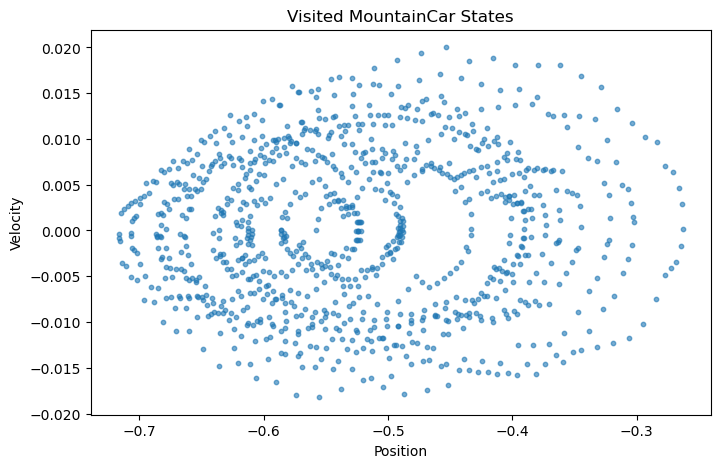

In [2]:
import matplotlib.pyplot as plt
import numpy as np

states = []
state, _ = env.reset()

done = False
while not done:
    states.append(state)
    action = env.action_space.sample()
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

states = np.array(states)

plt.figure(figsize=(8, 5))
plt.scatter(states[:, 0], states[:, 1], s=10, alpha=0.6)
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Visited MountainCar States")
plt.show()




In [3]:
n_pos_bins = 10
n_vel_bins = 10
pos_bins = np.linspace(env.observation_space.low[0], env.observation_space.high[0], n_pos_bins - 1)
vel_bins = np.linspace(env.observation_space.low[1], env.observation_space.high[1], n_vel_bins - 1) 
def discretize_state(state):
    pos, vel = state
    pos_bin = np.digitize(pos, pos_bins)
    vel_bin = np.digitize(vel, vel_bins)
    return pos_bin, vel_bin

def choose_action(Q, state, epsilon): # epsilon-greedy policy
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state[0], state[1], :])

def train_q_learning(episodes=5000, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_decay=0.999, epsilon_min=0.01):
    Q = np.zeros((n_pos_bins, n_vel_bins, env.action_space.n))
    rewards = []
    for episode in range(episodes):
        state, _ = env.reset()
        state = discretize_state(state)
        done = False
        total_reward = 0
        while not done:
            action = choose_action(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = discretize_state(next_state)
            done = terminated or truncated
            
            best_next_q = np.max(Q[next_state[0], next_state[1], :])
            Q[state[0], state[1], action] += alpha * (reward + gamma * best_next_q - Q[state[0], state[1], action])
            
            state = next_state
            total_reward += reward
        
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        rewards.append(total_reward)
    return Q, rewards


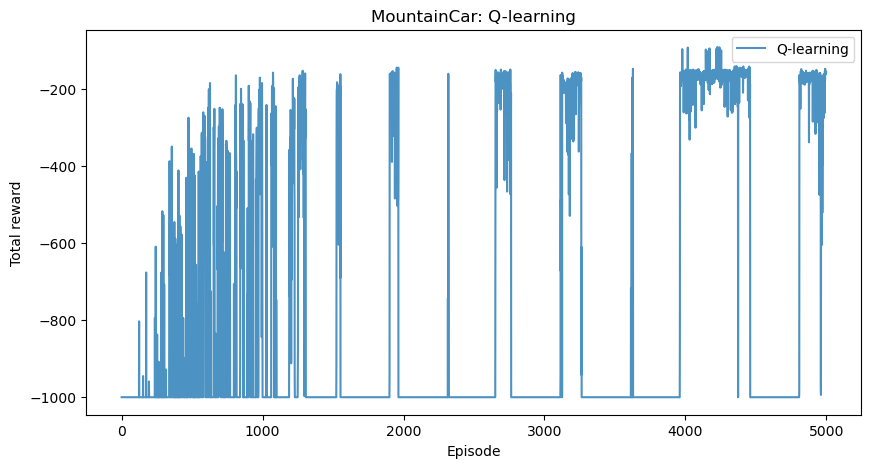

In [19]:
Q_q, rewards_q = train_q_learning()


plt.figure(figsize=(10, 5))
plt.plot(rewards_q, label="Q-learning", alpha=0.8)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("MountainCar: Q-learning")
plt.legend()
plt.show()


In [4]:
bin_settings = [
    (8, 8),
    (12, 12),
    (18, 14),
    (24, 18),
    (30, 30),
]


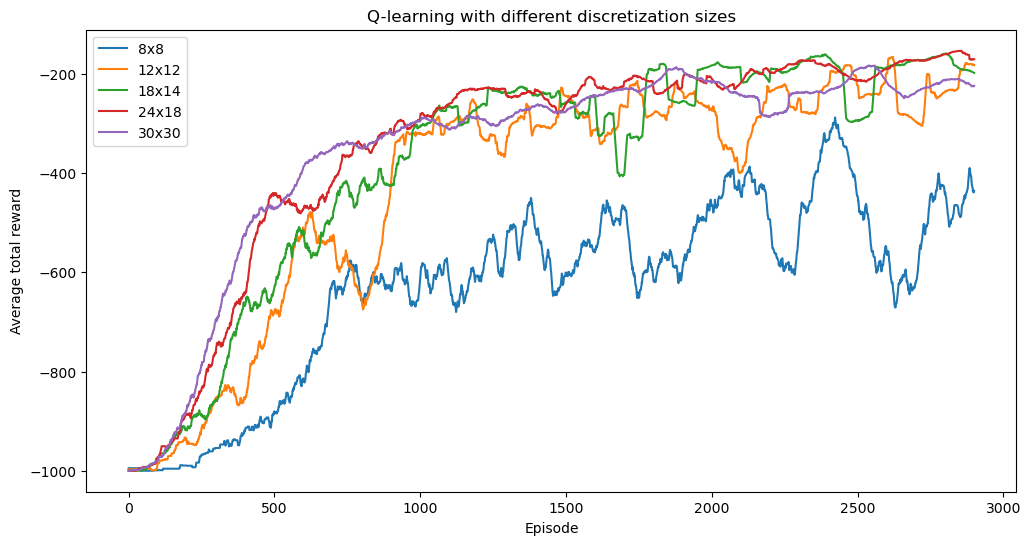

Bins (8, 8): average reward over last 100 episodes = -435.81
Bins (12, 12): average reward over last 100 episodes = -182.71
Bins (18, 14): average reward over last 100 episodes = -197.84
Bins (24, 18): average reward over last 100 episodes = -170.04
Bins (30, 30): average reward over last 100 episodes = -223.87


In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("MountainCar-v0", max_episode_steps=1000)

def make_bins(n_pos_bins, n_vel_bins): # Create bins for position and velocity
    pos_bins = np.linspace(-1.2, 0.6, n_pos_bins - 1) # I checked the observation space of the environment to get these limits
    vel_bins = np.linspace(-0.07, 0.07, n_vel_bins - 1)
    return pos_bins, vel_bins

def discretize_state(state, pos_bins, vel_bins): # Discretize the continuous state into bins
    position, velocity = state
    pos_idx = np.digitize(position, pos_bins)
    vel_idx = np.digitize(velocity, vel_bins)
    return (pos_idx, vel_idx)

def choose_action(Q, state, epsilon): # epsilon-greedy policy
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state[0], state[1], :])

def train_q_learning_with_bins(
    n_pos_bins,
    n_vel_bins,
    episodes=3000,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
):
    pos_bins, vel_bins = make_bins(n_pos_bins, n_vel_bins)
    Q = np.zeros((n_pos_bins, n_vel_bins, env.action_space.n))
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        state = discretize_state(state, pos_bins, vel_bins)

        done = False
        total_reward = 0

        while not done:
            action = choose_action(Q, state, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, pos_bins, vel_bins)
            done = terminated or truncated

            best_next_action = np.argmax(Q[next_state[0], next_state[1], :])

            Q[state[0], state[1], action] += alpha * (
                reward
                + gamma * Q[next_state[0], next_state[1], best_next_action]
                - Q[state[0], state[1], action]
            )

            state = next_state
            total_reward += reward

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return Q, rewards

results = {}

for n_pos_bins, n_vel_bins in bin_settings: # Train Q-learning with the current bin settings and store rewards
    _, rewards = train_q_learning_with_bins(n_pos_bins, n_vel_bins)
    results[(n_pos_bins, n_vel_bins)] = rewards

def moving_average(x, w=100): # Simple moving average to smooth the reward curves for better visualization
    return np.convolve(x, np.ones(w) / w, mode="valid") # This is only for visualization purposes, it doesn't affect the actual rewards or learning process

plt.figure(figsize=(12, 6))

for setting, rewards in results.items():
    plt.plot(moving_average(rewards, 100), label=f"{setting[0]}x{setting[1]}")

plt.xlabel("Episode")
plt.ylabel("Average total reward")
plt.title("Q-learning with different discretization sizes")
plt.legend()
plt.show()

for setting, rewards in results.items():
    final_avg = np.mean(rewards[-100:])
    print(f"Bins {setting}: average reward over last 100 episodes = {final_avg:.2f}")


As we see, the Q-learning gets the best rewards when we use a discretization step of 24 for position and 18. (out of the ones that we tested)

# 4.3
Another form of feature engineering is to normalize the input features to make both features contribute more evenly, as well as improving the numerical stability.

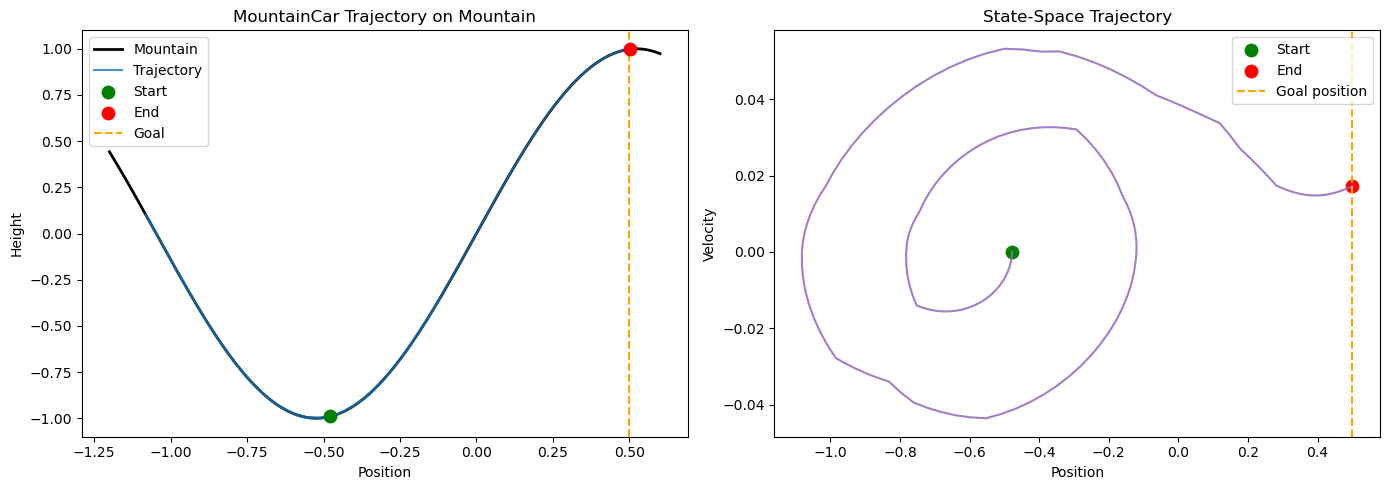

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

env = gym.make("MountainCar-v0", max_episode_steps=1000)

def run_greedy_episode(Q, pos_bins, vel_bins): # Only for my own visualization
    def discretize_state(state):
        position, velocity = state
        pos_idx = np.digitize(position, pos_bins)
        vel_idx = np.digitize(velocity, vel_bins)
        return (pos_idx, vel_idx)

    state, _ = env.reset()
    done = False

    states = [state.copy()]
    actions = []

    while not done:
        ds = discretize_state(state)
        action = np.argmax(Q[ds[0], ds[1], :])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        actions.append(action)
        states.append(next_state.copy())
        state = next_state

    return np.array(states), np.array(actions)

states, actions = run_greedy_episode(Q_q, pos_bins, vel_bins)

positions = states[:, 0]
velocities = states[:, 1]

x = np.linspace(-1.2, 0.6, 400)
y = np.sin(3 * x)
traj_y = np.sin(3 * positions)
goal_position = 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, y, color="black", linewidth=2, label="Mountain")
axes[0].plot(positions, traj_y, color="tab:blue", alpha=0.8, label="Trajectory")
axes[0].scatter(positions[0], traj_y[0], color="green", s=80, label="Start", zorder=3)
axes[0].scatter(positions[-1], traj_y[-1], color="red", s=80, label="End", zorder=3)
axes[0].axvline(goal_position, color="orange", linestyle="--", label="Goal")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Height")
axes[0].set_title("MountainCar Trajectory on Mountain")
axes[0].legend()

axes[1].plot(positions, velocities, color="tab:purple", alpha=0.85)
axes[1].scatter(positions[0], velocities[0], color="green", s=80, label="Start")
axes[1].scatter(positions[-1], velocities[-1], color="red", s=80, label="End")
axes[1].axvline(goal_position, color="orange", linestyle="--", label="Goal position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Velocity")
axes[1].set_title("State-Space Trajectory")
axes[1].legend()

plt.tight_layout()
plt.show()


# Exercise 5
5.1


In [1]:
from collections import defaultdict
import numpy as np
data = np.loadtxt("powered_flight.txt", dtype=int)

# Work on copies so the raw dataset remains 1-indexed for later cells.
s1 = data[:, 0].copy()
s2 = data[:, 1].copy()
a = data[:, 2].copy()
r  = data[:, 3].copy()
ns1 = data[:, 4].copy()
ns2 = data[:, 5].copy()

n_s1 = int(data[:, [0, 4]].max())   # 25
n_s2 = int(data[:, [1, 5]].max())   # 64
n_a  = int(data[:, 2].max())        # 2

# Convert local arrays to 0-indexed for model-estimation dictionaries.
s1 -= 1
s2 -= 1
a  -= 1
ns1 -= 1
ns2 -= 1

transition_counts = defaultdict(int)
sa_counts = defaultdict(int)
reward_sums = defaultdict(float)

for i in range(len(data)):
    s = (s1[i], s2[i])
    action = a[i]
    sp = (ns1[i], ns2[i])  # next state
    
    transition_counts[(s, action, sp)] += 1
    sa_counts[(s, action)] += 1
    reward_sums[(s, action)] += r[i]

# P(s' | s, a) - transition probabilities
P = defaultdict(float)
for (s, act, sp), count in transition_counts.items():
    P[(s, act, sp)] = count / sa_counts[(s, act)]

# Reward function R(s, a)
R = defaultdict(float)
for (s, act), count in sa_counts.items():
    R[(s, act)] = reward_sums[(s, act)] / count

In [2]:
# Dyna Q
# Same initialization as last task


Q = np.zeros((n_s1, n_s2, n_a))

# update model
model = {}
visited_sa = []

def update_model(s, a, r, sp):
    key = (s[0], s[1], a)

    if key not in model:
        model[key] = {
            "next_state_counts": defaultdict(int),
            "reward_sum": 0.0,
            "visit_count": 0
        }
        visited_sa.append(key)
    
    model[key]["next_state_counts"][sp] += 1 # Update transition count
    model[key]["reward_sum"] += r # Update reward sum
    model[key]["visit_count"] += 1 # Update amount of times we have seen this (s, a) pair

# function to simulate trajectorie
def sample_from_model(s, a):
    key = (s[0], s[1], a)
    entry = model[key] # Getting the stored model entry for this (s, a) pair, including the next state counts
    next_states = list(entry["next_state_counts"].keys()) # All possible next states we have seen for this (s, a) pair
    counts = np.array(list(entry["next_state_counts"].values()), dtype=float) # The counts for each of those next states
    probs = counts / counts.sum() # Normalizing to get probabilities for transitioning to each state

    # sample a next state based on the observed transition probabilities
    idx = np.random.choice(len(next_states), p=probs)
    sp = next_states[idx] # Sampled next state
    r = entry["reward_sum"] / entry["visit_count"] # Average reward observed for (s,a )
    
    return r, sp


# dyna q learning loop
def dyna_q(
    data,
    Q,
    episodes=1000,
    alpha=0.1,
    gamma=0.99,
    n_planning_steps = 10,
    n_passes = 20,
):
    td_errors = []
    
    for _ in range(n_passes):
        np.random.shuffle(data)

        for row in data: # Looping through the real experience data
            s = (int(row[0]) - 1, int(row[1]) - 1)
            a = int(row[2]) - 1
            r = float(row[3])
            sp = (int(row[4]) - 1, int(row[5]) - 1)
        
            # Update Q-values based on the real experience
            target = r + gamma * np.max(Q[sp[0], sp[1], :]) # Q-learning update target
            td_error = target - Q[s[0], s[1], a] # TD error for this real experience
            Q[s[0], s[1], a] += alpha * td_error # Q-learning update
            td_errors.append(abs(td_error)) # Storing the absolute TD error for this real experience

            update_model(s, a, r, sp) # Update the model with this real experience

            if visited_sa: # Only do planning updates if we have at least one (s, a) pair in our model
                for _ in range(n_planning_steps):
                    k = visited_sa[np.random.randint(len(visited_sa))] # Randomly sample a (s, a) pair we have seen before
                    s_plan = (k[0], k[1]) # State
                    a_plan = k[2] # Action
                    r_plan, sp_plan = sample_from_model(s_plan, a_plan) # Simulate a transition using our function

                    plan_target = r_plan + gamma * np.max(Q[sp_plan[0], sp_plan[1], :]) # Q-learning update target for the simulated experience
                    Q[s_plan[0], s_plan[1], a_plan] += alpha * (plan_target - Q[s_plan[0], s_plan[1], a_plan]) # Q-learning update for the simulated experience

    return Q, td_errors

Q_dyna, td_errors = dyna_q(data.copy(), Q)
policy = np.argmax(Q_dyna, axis=2) + 1 # Adding 1 to convert back to 1-indexed action space
print("Learned policy (action indices):")
print(policy)
    
    

Learned policy (action indices):
[[1 1 1 ... 1 2 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 2]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


Trajectory in environment coordinates (0-indexed):
[(13, 5), (13, 9), (10, 19), (8, 23), (7, 26), (2, 29), (3, 34), (4, 36), (5, 38), (6, 34), (7, 36), (8, 55), (9, 58), (10, 61), (13, 58), (14, 54)]

Trajectory in file coordinates (1-indexed):
[(14, 6), (14, 10), (11, 20), (9, 24), (8, 27), (3, 30), (4, 35), (5, 37), (6, 39), (7, 35), (8, 37), (9, 56), (10, 59), (11, 62), (14, 59), (15, 55)]

Actions along trajectory (1-indexed):
[2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1]

Reached goal: True


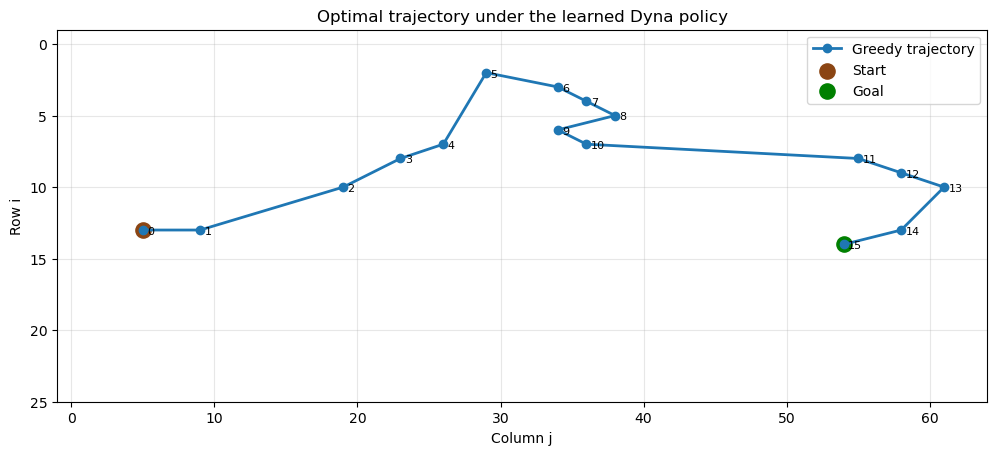

In [ ]:
# Plot the greedy trajectory learned by Dyna
import numpy as np
import matplotlib.pyplot as plt

# Coordinates from the PDF are in 0-indexed environment coordinates.
start_state_env = (13, 5)
goal_state_env = (14, 54)

def available_actions(s, model_table=None):
    if model_table is None:
        model_table = model

    return [a for a in range(n_a) if (s[0], s[1], a) in model_table]

def greedy_action_from_model(s, Q_table=None, model_table=None): #
    if Q_table is None:
        Q_table = Q_dyna

    actions = available_actions(s, model_table=model_table)

    if not actions:
        return None

    return max(actions, key=lambda a: Q_table[s[0], s[1], a])

def most_likely_transition(s, a, model_table=None):
    if model_table is None:
        model_table = model

    key = (s[0], s[1], a)
    entry = model_table[key]
    sp = max(entry["next_state_counts"], key=entry["next_state_counts"].get)
    r = entry["reward_sum"] / entry["visit_count"]

    return r, sp

def rollout_greedy_trajectory(start_state, goal_state, Q_table=None, model_table=None, max_steps=200, verbose=True):
    if Q_table is None:
        Q_table = Q_dyna

    if model_table is None:
        model_table = model

    trajectory = [start_state]
    actions = []
    s = start_state

    for _ in range(max_steps):
        if s == goal_state:
            break

        a = greedy_action_from_model(s, Q_table=Q_table, model_table=model_table)

        if a is None:
            if verbose:
                print(f"Stopped rollout at state {s} because the learned model has no outgoing actions there.")
            break

        actions.append(a)

        r, sp = most_likely_transition(s, a, model_table=model_table)
        trajectory.append(sp)

        if r == 1 or sp == goal_state:
            break

        if sp in trajectory[:-1]:
            if verbose:
                print("Loop detected before reaching the goal.")
            break

        s = sp

    return trajectory, actions

# Model states are now also 0-indexed, so no offset conversion is needed.
trajectory_env, actions_0idx = rollout_greedy_trajectory(start_state_env, goal_state_env)
trajectory_file = [(s[0] + 1, s[1] + 1) for s in trajectory_env]
actions_1idx = [a + 1 for a in actions_0idx]

print("Trajectory in environment coordinates (0-indexed):")
print(trajectory_env)
print("\nTrajectory in file coordinates (1-indexed):")
print(trajectory_file)
print("\nActions along trajectory (1-indexed):")
print(actions_1idx)
print("\nReached goal:", trajectory_env[-1] == goal_state_env)

rows = [s[0] for s in trajectory_env]
cols = [s[1] for s in trajectory_env]

plt.figure(figsize=(12, 6))
plt.plot(cols, rows, marker="o", linewidth=2, color="tab:blue", label="Greedy trajectory")
plt.scatter(start_state_env[1], start_state_env[0], color="saddlebrown", s=120, label="Start")
plt.scatter(goal_state_env[1], goal_state_env[0], color="green", s=120, label="Goal")

for step, (row, col) in enumerate(trajectory_env):
    plt.text(col + 0.3, row + 0.3, str(step), fontsize=8)

plt.gca().invert_yaxis()
plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(-1, n_s2)
plt.ylim(n_s1, -1)
plt.xlabel("Column j")
plt.ylabel("Row i")
plt.title("Optimal trajectory under the learned Dyna policy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5.4
Run Dyna-Q with different numbers of planning simulations (`n_planning_steps`) and compare the results.

To compare learning speed, record pass-by-pass mean absolute TD error and the first pass where the greedy rollout reaches the goal.

Dyna-Q with different numbers of planning simulations
n_plan | reached_goal | steps | final_mean_abs_td | first_goal_pass
------------------------------------------------------------------------
     0 |         True |    15 |            0.0088 |               8
     1 |         True |    15 |            0.0330 |               4
     5 |         True |    15 |            0.0604 |               2
    10 |         True |    15 |            0.0137 |               1
    20 |         True |    15 |            0.0000 |               1
    50 |         True |    15 |            0.0000 |               1

Policy differences compared with n_plan = 0:
n_plan =  1: 21 states choose a different greedy action
n_plan =  5: 21 states choose a different greedy action
n_plan = 10: 24 states choose a different greedy action
n_plan = 20: 25 states choose a different greedy action
n_plan = 50: 22 states choose a different greedy action


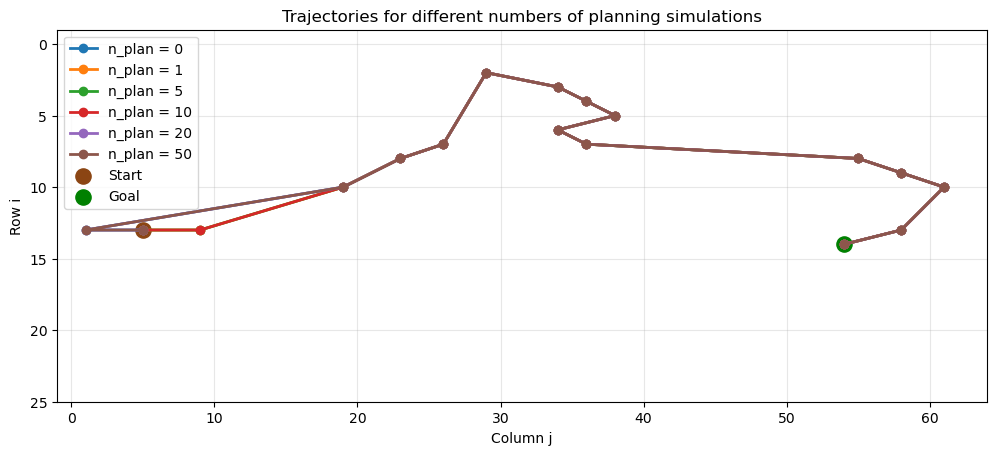

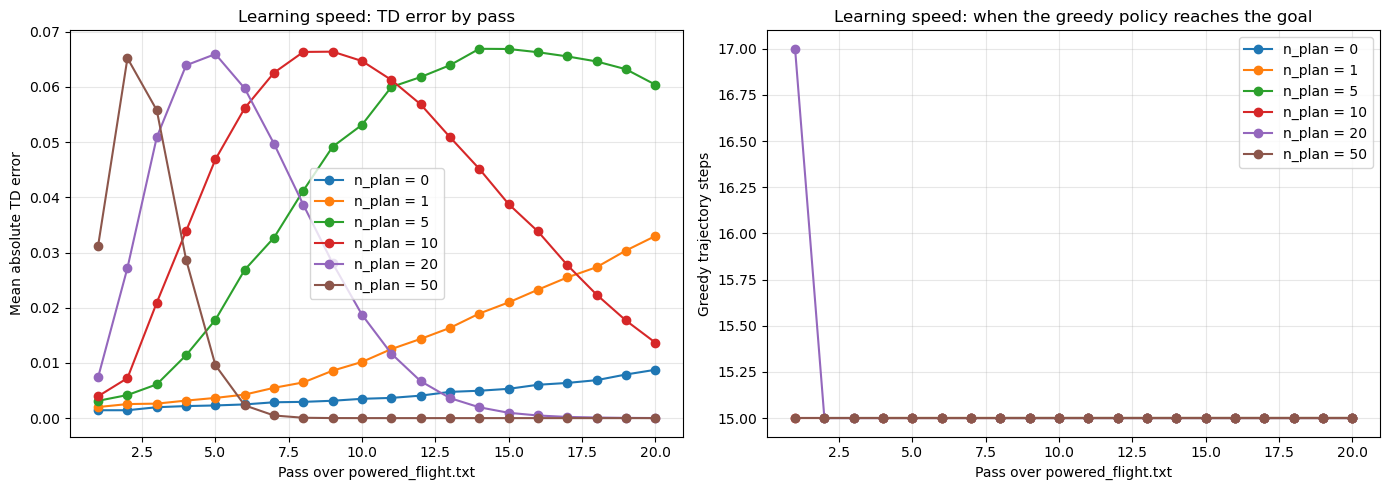

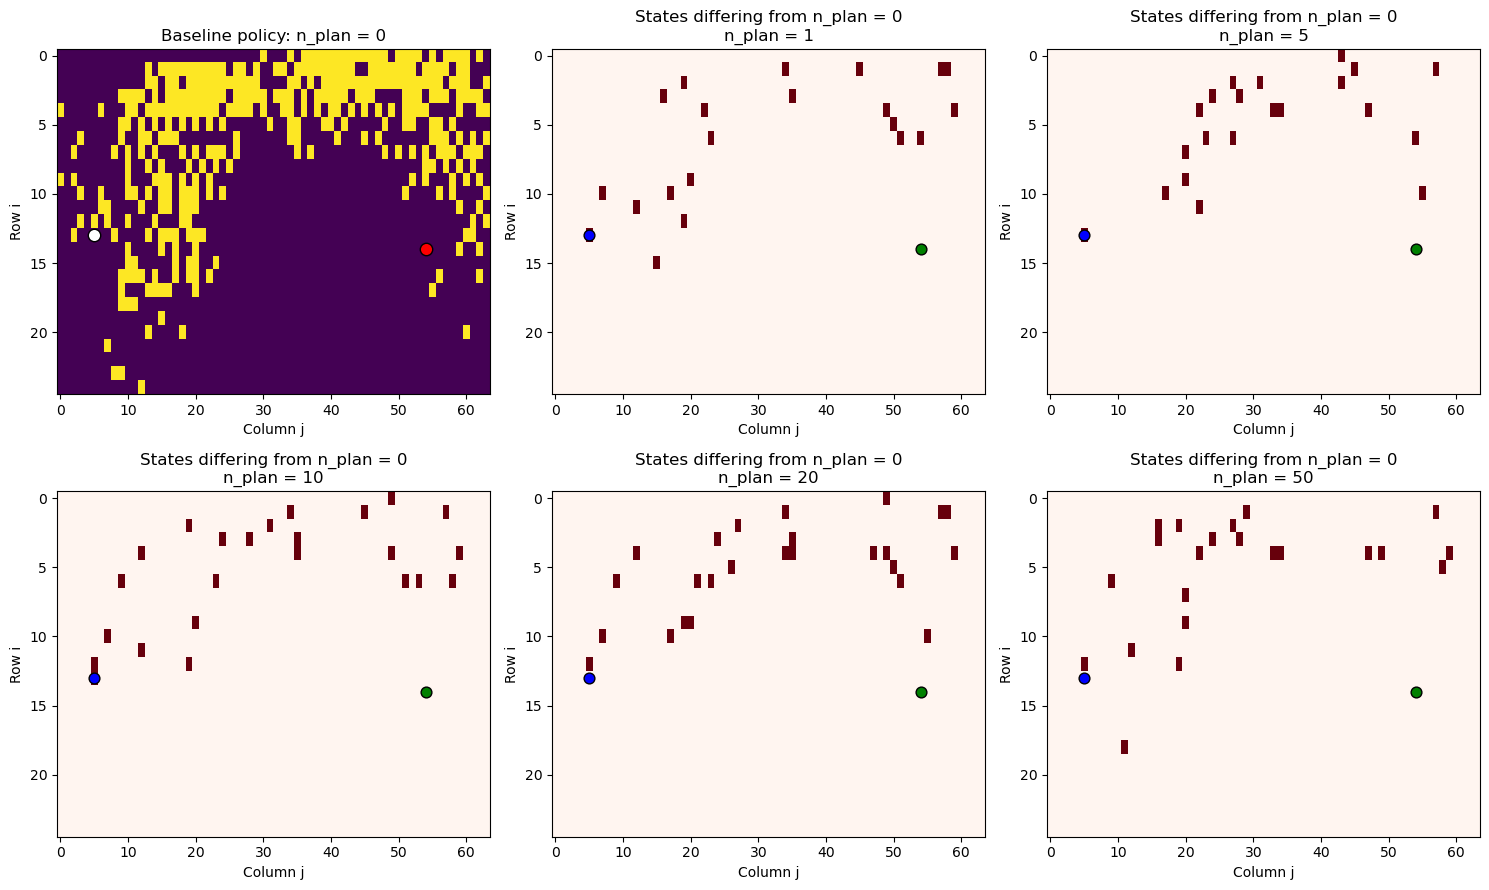

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Compare both final performance and learning speed as n_planning_steps changes.
planning_steps_list = [0, 1, 5, 10, 20, 50]
simple_results = []
trajectory_results = {}
policy_results = {}
progress_results = {}

def dyna_q_with_history(data, n_planning_steps, alpha=0.1, gamma=0.99, n_passes=20):
    Q_run = np.zeros((n_s1, n_s2, n_a))
    model_run = {}
    visited_sa_run = []
    td_errors_run = []
    history = []

    def update_model_run(s, a, r, sp):
        key = (s[0], s[1], a)

        if key not in model_run:
            model_run[key] = {
                "next_state_counts": defaultdict(int),
                "reward_sum": 0.0,
                "visit_count": 0,
            }
            visited_sa_run.append(key)

        model_run[key]["next_state_counts"][sp] += 1
        model_run[key]["reward_sum"] += r
        model_run[key]["visit_count"] += 1

    def sample_from_model_run(s, a):
        entry = model_run[(s[0], s[1], a)]
        next_states = list(entry["next_state_counts"].keys())
        counts = np.array(list(entry["next_state_counts"].values()), dtype=float)
        probs = counts / counts.sum()
        sp = next_states[np.random.choice(len(next_states), p=probs)]
        r = entry["reward_sum"] / entry["visit_count"]
        return r, sp

    for pass_index in range(n_passes):
        np.random.shuffle(data)
        pass_td_errors = []

        for row in data:
            s = (int(row[0]) - 1, int(row[1]) - 1)
            a = int(row[2]) - 1
            r = float(row[3])
            sp = (int(row[4]) - 1, int(row[5]) - 1)

            target = r + gamma * np.max(Q_run[sp[0], sp[1], :])
            td_error = target - Q_run[s[0], s[1], a]
            Q_run[s[0], s[1], a] += alpha * td_error

            abs_td = abs(td_error)
            pass_td_errors.append(abs_td)
            td_errors_run.append(abs_td)

            update_model_run(s, a, r, sp)

            for _ in range(n_planning_steps):
                k = visited_sa_run[np.random.randint(len(visited_sa_run))]
                s_pl, a_pl = (k[0], k[1]), k[2]
                r_pl, sp_pl = sample_from_model_run(s_pl, a_pl)
                plan_target = r_pl + gamma * np.max(Q_run[sp_pl[0], sp_pl[1], :])
                Q_run[s_pl[0], s_pl[1], a_pl] += alpha * (plan_target - Q_run[s_pl[0], s_pl[1], a_pl])

        trajectory_pass, actions_pass = rollout_greedy_trajectory(
            start_state_env,
            goal_state_env,
            Q_table=Q_run,
            model_table=model_run,
            max_steps=300,
            verbose=False,
        )

        history.append({
            "pass": pass_index + 1,
            "mean_abs_td": float(np.mean(pass_td_errors)),
            "reached_goal": trajectory_pass[-1] == goal_state_env,
            "steps": len(actions_pass),
        })

    return Q_run, model_run, visited_sa_run, td_errors_run, history

for n_plan in planning_steps_list:
    np.random.seed(0)
    Q_run, model_run, visited_sa_run, td_errors_run, history = dyna_q_with_history(
        data.copy(),
        n_planning_steps=n_plan,
        alpha=0.1,
        gamma=0.99,
        n_passes=20,
    )

    trajectory, actions = rollout_greedy_trajectory(
        start_state_env,
        goal_state_env,
        Q_table=Q_run,
        model_table=model_run,
        max_steps=300,
        verbose=False,
    )
    reached_goal = trajectory[-1] == goal_state_env
    steps = len(actions)
    mean_td = history[-1]["mean_abs_td"]
    first_goal_pass = next((item["pass"] for item in history if item["reached_goal"]), None)

    simple_results.append((n_plan, reached_goal, steps, mean_td, first_goal_pass))
    trajectory_results[n_plan] = trajectory
    policy_results[n_plan] = np.argmax(Q_run, axis=2)
    progress_results[n_plan] = history

print("Dyna-Q with different numbers of planning simulations")
print(f"{'n_plan':>6} | {'reached_goal':>12} | {'steps':>5} | {'final_mean_abs_td':>17} | {'first_goal_pass':>15}")
print("-" * 72)
for n_plan, reached_goal, steps, mean_td, first_goal_pass in simple_results:
    first_goal_text = 'never' if first_goal_pass is None else str(first_goal_pass)
    print(f"{n_plan:>6} | {str(reached_goal):>12} | {steps:>5} | {mean_td:>17.4f} | {first_goal_text:>15}")

baseline_plan = planning_steps_list[0]
baseline_policy = policy_results[baseline_plan]
print()
print("Policy differences compared with n_plan = 0:")
for n_plan in planning_steps_list[1:]:
    different_states = int(np.sum(policy_results[n_plan] != baseline_policy))
    print(f"n_plan = {n_plan:>2}: {different_states} states choose a different greedy action")

plt.figure(figsize=(12, 6))
for n_plan, trajectory in trajectory_results.items():
    rows = [state[0] for state in trajectory]
    cols = [state[1] for state in trajectory]
    plt.plot(cols, rows, marker='o', linewidth=2, label=f'n_plan = {n_plan}')

plt.scatter(start_state_env[1], start_state_env[0], color='saddlebrown', s=120, label='Start')
plt.scatter(goal_state_env[1], goal_state_env[0], color='green', s=120, label='Goal')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-1, n_s2)
plt.ylim(n_s1, -1)
plt.xlabel('Column j')
plt.ylabel('Row i')
plt.title('Trajectories for different numbers of planning simulations')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_plan, history in progress_results.items():
    passes = [item['pass'] for item in history]
    mean_td_curve = [item['mean_abs_td'] for item in history]
    steps_curve = [item['steps'] if item['reached_goal'] else np.nan for item in history]
    axes[0].plot(passes, mean_td_curve, marker='o', label=f'n_plan = {n_plan}')
    axes[1].plot(passes, steps_curve, marker='o', label=f'n_plan = {n_plan}')

axes[0].set_xlabel('Pass over powered_flight.txt')
axes[0].set_ylabel('Mean absolute TD error')
axes[0].set_title('Learning speed: TD error by pass')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Pass over powered_flight.txt')
axes[1].set_ylabel('Greedy trajectory steps')
axes[1].set_title('Learning speed: when the greedy policy reaches the goal')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

comparison_plans = planning_steps_list[1:]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

axes[0].imshow(baseline_policy, origin='upper', cmap='viridis', aspect='auto')
axes[0].scatter(start_state_env[1], start_state_env[0], color='white', s=80, edgecolor='black')
axes[0].scatter(goal_state_env[1], goal_state_env[0], color='red', s=80, edgecolor='black')
axes[0].set_title('Baseline policy: n_plan = 0')
axes[0].set_xlabel('Column j')
axes[0].set_ylabel('Row i')

for index, n_plan in enumerate(comparison_plans, start=1):
    diff_mask = (policy_results[n_plan] != baseline_policy).astype(int)
    axes[index].imshow(diff_mask, origin='upper', cmap='Reds', aspect='auto', vmin=0, vmax=1)
    axes[index].scatter(start_state_env[1], start_state_env[0], color='blue', s=60, edgecolor='black')
    axes[index].scatter(goal_state_env[1], goal_state_env[0], color='green', s=60, edgecolor='black')
    axes[index].set_title(f'States differing from n_plan = 0\nn_plan = {n_plan}')
    axes[index].set_xlabel('Column j')
    axes[index].set_ylabel('Row i')

plt.tight_layout()
plt.show()